# Preprocess Data

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

## Clean Data

In [2]:
df = pd.read_excel('HFpEF-research-4.4.xlsx', skiprows=[1,2,3,4,5,6,7,8,9])

In [3]:
df = df.drop(columns=['participant number', 'time to mortality after diagnosis', 'time to HF hospitalization after diagnosis', 'SSRI', 'censor (death)', 'censor (HF)', 'censor (MACE)', 'time to MACE'])

In [5]:
df.columns

Index(['Age', 'Sex', 'Cr', 'GFR', 'CKD stage', 'smoke', 'BMI', 'BSA', 'DM',
       'Insulin', 'AF', 'SBP', 'DBP', 'MAP', 'PP', '1/2SBP', 'wide PP', 'HT',
       'HR', 'ACE-i', 'ARB', 'ARNI', 'betablocker', 'Aspirin', 'SGLT2i', 'MRA',
       'MI', 'stroke', 'COPD', 'NYHA', 'edema', 'Death', 'CV death',
       'HF re-hospitalization', 'Major cardiac events', 'NTProBNP',
       'medial a'', 'medial E'', 'lateral E'', 'average e/E'', 'lateral e/E'',
       'E/A', 'Mitral E/e'', 'TR Vmax', 'RWT', 'LV mass index', 'LVH', 'LAVI',
       'LACI', 'LA diameter', 'LVEF'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405 entries, 0 to 404
Data columns (total 51 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    405 non-null    int64  
 1   Sex                    405 non-null    int64  
 2   Cr                     405 non-null    float64
 3   GFR                    405 non-null    float64
 4   CKD stage              405 non-null    int64  
 5   smoke                  28 non-null     float64
 6   BMI                    389 non-null    float64
 7   BSA                    399 non-null    float64
 8   DM                     405 non-null    int64  
 9   Insulin                405 non-null    int64  
 10  AF                     405 non-null    int64  
 11  SBP                    405 non-null    int64  
 12  DBP                    405 non-null    int64  
 13  MAP                    405 non-null    float64
 14  PP                     405 non-null    int64  
 15  1/2SBP

In [7]:
df = df.copy()

In [8]:
df.loc[df['HF re-hospitalization']==2,'HF re-hospitalization'] = 1

In [9]:
df.loc[df['AF']==9,'AF'] = 0

In [10]:
df.dropna(subset = ["Major cardiac events", 'HF re-hospitalization'], inplace=True)

In [11]:
df['NTProBNP'].unique()

array([4169, 732, nan, 3493, 4060, 2851, 1017, '>35,000', 942, 4292, 1487,
       451.9, 2351, 3841, 458.2, 976, 4382, 1153, 1316, '> 35000', 436.1,
       12887, 894, 15026, 33177, 4167, 9860, 858.1, 17796, 6859, 11291,
       25202, 3011, 7348, 625.7, 21777, 1274, 1040, 4877, 1051, 1196,
       25766, 3195, 1362, 65.7, 6720, 29430, 478.4, 8131, 4792, 8677,
       6620, 23893, 1042, 1608, 41.74, 15119, 2636, 1711, 1293, 1490,
       7924, 3382, 963, 348, 25094, 5944, 2114, 721, 1590, 2011, 675.9,
       4204, 293, 235.9, 8.32, 2176, 137, 178.6, 703.8, 9351, 1030, 140,
       164, 2251, 8600, 171.6, 195.9, 13624, 7633, 501.9, 3227, 2745,
       4242, 132.5, 3468, 1678, 309, 213.9, 3812, 4633, 5153, 2932, 5864,
       125, 1375, 3449, 6181, 141, '>35000', 1114, 1197, 3245, 862.7,
       1654, 2134, 8190, 209, 18122, 2733, 2255, 5456, 7716, 12687, 3757,
       2462, 420, 7569, 91.5, 2275, 3754, 1344, 7587, 6244, 5476, 2213,
       3133, 1484, 1796, 2624, 3924, 1858, 350, 1287, 79, 1321, 

In [12]:
df.loc[df['NTProBNP']=='>35,000','NTProBNP'] = 35001
df.loc[df['NTProBNP']=='> 35000','NTProBNP'] = 35001
df.loc[df['NTProBNP']=='>35000','NTProBNP'] = 35001

In [13]:
df['NTProBNP'] = df['NTProBNP'].astype('float')

In [14]:
df['LV mass index'].unique()

array([141.14, 84.6, 252, 129.7, 148.6, 143, 92.6, 98, 112.2, 97.1, 113.1,
       164, 94.7, 146.3, 73, 89.9, nan, 110.1, 76.4, 116.6, 119.3, 66.3,
       106, 47.4, 87.7, 94.6, 126, 71.6, 113, 117.8, 356.6, 114, 116.25,
       97.9, 157, 91.4, 204.9, 97.2, 69.1, 120.5, 95, 83.4, 102.7, 121.7,
       105.2, 130.1, 74.7, 216, 197.1, 98.3, 68.3, 130, 73.5, 126.4,
       119.8, 131.4, 86.5, 64.7, 90.2, 66.7, 174.7, 150, 53.8, 123.1,
       114.6, 107.6, 132.2, 239, 69.5, 67.5, 182.5, 117.4, 88.8, 103.4,
       212.9, 55.6, 122.3, 141.8, 129.5, 150.8, 123.7, 59.5, 148.1, 83.1,
       158.2, 116.1, 203.3, 129.9, 202.7, 126.7, 157.6, 131.7, 75.7, 75.6,
       153, 83, 94.4, 171.7, 90.4, 107.5, 67.8, 63, 130.9, 99.4, 188, 158,
       113.8, 145.4, 171.9, 255.6, 212.1, 96, 93.8, 113.3, 113.2, 121,
       112.5, 143.5, 167.4, 228, 145, '183,7', 159, 81.9, 79.9, 116.2,
       128.4, 196, 86.8, 88.6, 202.2, 127.5, 119, 132.3, 103, 179, 91.7,
       80.5, 75.5, 92.3, 185.6, 119.6, 81.2, 132.4, 75.

In [15]:
df.loc[df['LV mass index']=='183,7','LV mass index'] = 183.7

In [16]:
df['LV mass index'] = df['LV mass index'].astype('float')

In [17]:
df['smoke'] = df['smoke'].fillna(0)
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())
df['BSA'] = df['BSA'].fillna(df['BSA'].mean())
df['HR'] = df['HR'].fillna(df['HR'].mean().round())
df['stroke'] = df['stroke'].fillna(0)

In [18]:
np.round(df['HR'].mean())

77.0

In [19]:
df['BSA'].mean()

1.6360969387755102

In [20]:
df['BMI'].mean()

26.75628272251309

In [21]:
df['HR'].mean().round()

77.0

In [22]:
idx = df['LA diameter'].isnull()
((10.7 + (0.27 * df['LAVI'][idx]) + (10.6 * df['BSA'][idx])) / 10).min()

3.038

In [23]:
df['LA diameter'].min()

2.1

In [24]:
idx = df['LAVI'].isnull()
(((10 * df['LA diameter'][idx]) - (10.6 * df['BSA'][idx]) - 8.7) / 0.27).min()

-2.666666666666662

In [25]:
df['LAVI'].min()

9.5

LA diameter = 10.7 + 0.27 * LAVI + 10.6 * BSA

So

LAVI = (LA diameter - 10.6 * BSA - 10.7) / 0.27

https://onlinelibrary.wiley.com/doi/full/10.1111/echo.14943

In [26]:
idx = df['LA diameter'].isnull()
df.loc[idx, 'LA diameter'] = (10.7 + (0.27 * df['LAVI'][idx]) + (10.6 * df['BSA'][idx])) / 10

In [27]:
# idx = df['LAVI'].isnull()
# df.loc[idx, 'LAVI'] = ((10 * df['LA diameter'][idx]) - (10.6 * df['BSA'][idx]) - 10.7) / 0.27

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 398 entries, 0 to 404
Data columns (total 51 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    398 non-null    int64  
 1   Sex                    398 non-null    int64  
 2   Cr                     398 non-null    float64
 3   GFR                    398 non-null    float64
 4   CKD stage              398 non-null    int64  
 5   smoke                  398 non-null    float64
 6   BMI                    398 non-null    float64
 7   BSA                    398 non-null    float64
 8   DM                     398 non-null    int64  
 9   Insulin                398 non-null    int64  
 10  AF                     398 non-null    int64  
 11  SBP                    398 non-null    int64  
 12  DBP                    398 non-null    int64  
 13  MAP                    398 non-null    float64
 14  PP                     398 non-null    int64  
 15  1/2SBP

In [29]:
df = df.fillna(0)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 398 entries, 0 to 404
Data columns (total 51 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    398 non-null    int64  
 1   Sex                    398 non-null    int64  
 2   Cr                     398 non-null    float64
 3   GFR                    398 non-null    float64
 4   CKD stage              398 non-null    int64  
 5   smoke                  398 non-null    float64
 6   BMI                    398 non-null    float64
 7   BSA                    398 non-null    float64
 8   DM                     398 non-null    int64  
 9   Insulin                398 non-null    int64  
 10  AF                     398 non-null    int64  
 11  SBP                    398 non-null    int64  
 12  DBP                    398 non-null    int64  
 13  MAP                    398 non-null    float64
 14  PP                     398 non-null    int64  
 15  1/2SBP

## Displaying

In [31]:
lbl_colname= ['Death', 'CV death', 'Major cardiac events', 'HF re-hospitalization']

In [32]:
y = np.array(df[lbl_colname])
X = df.drop(lbl_colname, axis = 1)
# X = X[['Age', 'Sex', 'Cr', 'GFR', 'CKD stage', 'AF', 'MAP', 'PP', 'NTProBNP', "medial a'", "medial E'", 'LAVI', 'LA diameter']]
# Saving feature names for later use
feature_list = list(X.columns)
# # Convert to numpy array
X = np.array(X)

In [33]:
def plot_tsne(X_val, y, lbl_colname):
    f = plt.figure()
    plt.scatter(X_val[:, 0], X_val[:, 1], cmap=plt.cm.Spectral)
#     plt.gca().set_aspect('equal')
    fig, axes = plt.subplots(1, len(y[0]), figsize=(15, 4))
    for i in range(len(y[0])):
        print(np.unique(y[:,i]))
        scatter = axes[i].scatter(X_val[:, 0], X_val[:, 1], c=y[:,i], cmap=plt.cm.jet, alpha=0.5)
#         axes[i].set_aspect('equal')
        axes[i].legend(scatter.legend_elements()[0], ['No','Yes'], title="Classes")
        axes[i].set_title(f'{lbl_colname[i]}')

C:\Users\sguly\miniconda3\envs\hfpef\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]


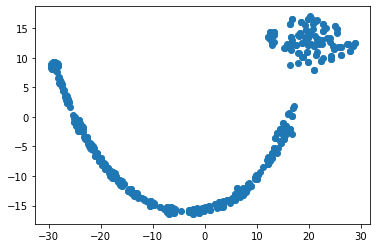

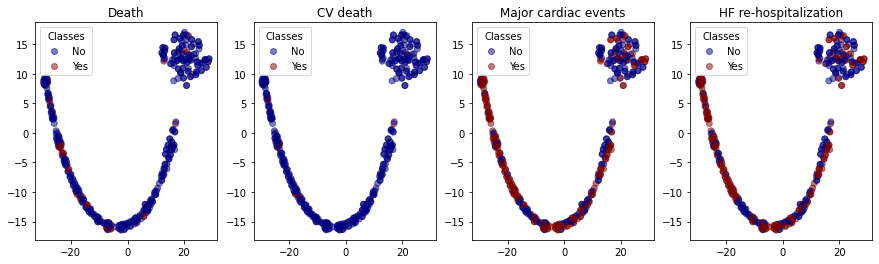

In [35]:
from sklearn.manifold import TSNE
X_embedded = TSNE(n_components=2, init='random').fit_transform(X)
plot_tsne(X_embedded, y, lbl_colname)
# plt.savefig("tsne_405.png")

[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]


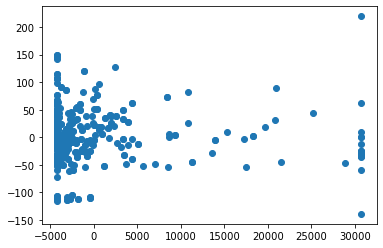

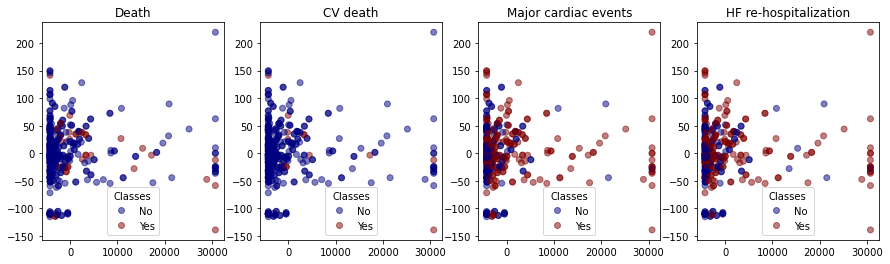

In [36]:
from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(X)
plot_tsne(X_pca, y, lbl_colname)

(array([285.,  50.,  21.,   8.,   4.,   4.,   5.,   3.,   1.,  17.]),
 array([-4251.56300249,  -751.42609009,  2748.71082231,  6248.84773471,
         9748.98464711, 13249.12155952, 16749.25847192, 20249.39538432,
        23749.53229672, 27249.66920912, 30749.80612152]),
 <BarContainer object of 10 artists>)

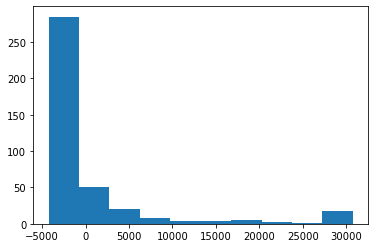

In [37]:
from sklearn.decomposition import PCA
pca_model = PCA(n_components=0.99)
X_pca = pca_model.fit_transform(X)
plt.hist(X_pca)

In [38]:
pca_model.explained_variance_ratio_

array([0.99991368])

In [39]:
for i,j in zip(feature_list, pca_model.components_.flatten()):
    print(i,j)

Age 5.663016425612089e-05
Sex -1.6849404336216622e-06
Cr 3.921060115494464e-05
GFR -0.0006974013518342929
CKD stage 2.9477823032391076e-05
smoke -1.2830432482749643e-06
BMI -0.0001567443811943143
BSA -2.702943948263266e-06
DM -4.62795031437924e-07
Insulin 1.2331805247114242e-06
AF 6.097311273043629e-07
SBP 0.00013515278021227536
DBP -7.559382753047177e-05
MAP -5.344958282890548e-06
PP 0.00021074660774274973
1/2SBP 6.757639010613768e-05
wide PP 5.157392250583568e-06
HT 2.7216745641076327e-06
HR 3.7652357809832976e-05
ACE-i -3.044351241711924e-06
ARB -5.947861209401653e-06
ARNI 6.2765918626104885e-06
betablocker 5.258040804779568e-06
Aspirin 2.774617192837322e-06
SGLT2i -3.8810751853755855e-06
MRA 2.081201983759126e-06
MI 1.1109296638694502e-05
stroke 7.435096374297783e-06
COPD -5.490658579568894e-07
NYHA -2.0952274411917816e-06
edema 3.0488798876523748e-06
NTProBNP 0.9999992312745936
medial a' 4.4236160098739944e-05
medial E' 4.544508197919716e-07
lateral E' -2.137256287477649e-05
avera

In [40]:
sorted(zip(feature_list, pca_model.components_.flatten()), key=lambda x: abs(x[1]), reverse=True)

[('NTProBNP', 0.9999992312745936),
 ('LV mass index', 0.0009308269564035371),
 ('GFR', -0.0006974013518342929),
 ('PP', 0.00021074660774274973),
 ('LAVI', -0.00016998269009445548),
 ('BMI', -0.0001567443811943143),
 ("Mitral E/e'", 0.00014075425600617865),
 ('SBP', 0.00013515278021227536),
 ("lateral e/E'", 0.00010772539535913012),
 ("average e/E'", 0.00010669036982877654),
 ('DBP', -7.559382753047177e-05),
 ('1/2SBP', 6.757639010613768e-05),
 ('LVEF', 5.843253021615546e-05),
 ('Age', 5.663016425612089e-05),
 ("medial a'", 4.4236160098739944e-05),
 ('LVH', 4.311553299072318e-05),
 ('Cr', 3.921060115494464e-05),
 ('HR', 3.7652357809832976e-05),
 ('CKD stage', 2.9477823032391076e-05),
 ("lateral E'", -2.137256287477649e-05),
 ('LACI', 1.1945397019590863e-05),
 ('MI', 1.1109296638694502e-05),
 ('E/A', 9.14982237426213e-06),
 ('stroke', 7.435096374297783e-06),
 ('TR Vmax', 7.377185698202401e-06),
 ('ARNI', 6.2765918626104885e-06),
 ('ARB', -5.947861209401653e-06),
 ('MAP', -5.3449582828905

In [41]:
pca_model.components_.flatten()

array([ 5.66301643e-05, -1.68494043e-06,  3.92106012e-05, -6.97401352e-04,
        2.94778230e-05, -1.28304325e-06, -1.56744381e-04, -2.70294395e-06,
       -4.62795031e-07,  1.23318052e-06,  6.09731127e-07,  1.35152780e-04,
       -7.55938275e-05, -5.34495828e-06,  2.10746608e-04,  6.75763901e-05,
        5.15739225e-06,  2.72167456e-06,  3.76523578e-05, -3.04435124e-06,
       -5.94786121e-06,  6.27659186e-06,  5.25804080e-06,  2.77461719e-06,
       -3.88107519e-06,  2.08120198e-06,  1.11092966e-05,  7.43509637e-06,
       -5.49065858e-07, -2.09522744e-06,  3.04887989e-06,  9.99999231e-01,
        4.42361601e-05,  4.54450820e-07, -2.13725629e-05,  1.06690370e-04,
        1.07725395e-04,  9.14982237e-06,  1.40754256e-04,  7.37718570e-06,
       -9.97598068e-07,  9.30826956e-04,  4.31155330e-05, -1.69982690e-04,
        1.19453970e-05, -3.32934978e-06,  5.84325302e-05])

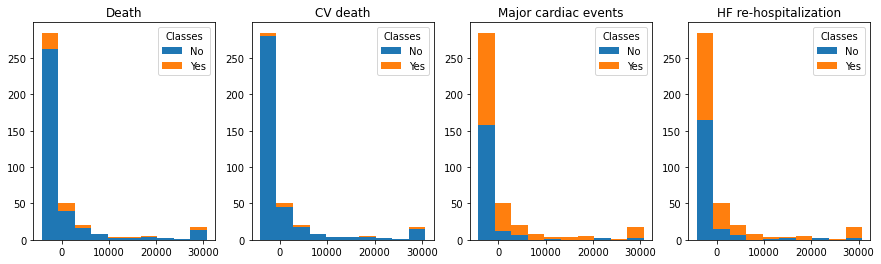

In [42]:
fig, axes = plt.subplots(1, len(y[0]), figsize=(15, 4))
for i in range(len(y[0])):
    hist = axes[i].hist([X_pca[y[:,i]==0].ravel(),X_pca[y[:,i]==1].ravel()], stacked=True)
    axes[i].legend(['No','Yes'], title="Classes")
    axes[i].set_title(f'{lbl_colname[i]}')
plt.savefig("pca_405.png")

[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]


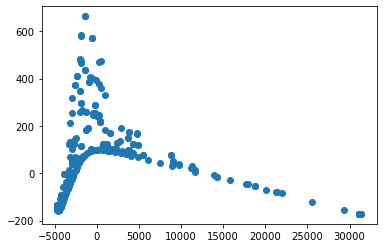

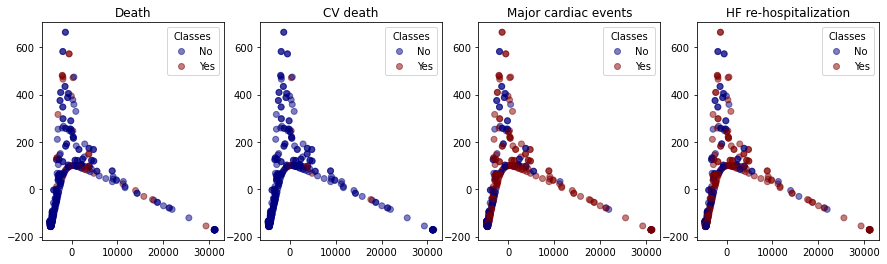

In [43]:
from sklearn.manifold import Isomap
X_iso = Isomap(n_neighbors=10, n_components=2).fit_transform(X)
plot_tsne(X_iso, y, lbl_colname)

In [44]:
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=3,eigen_solver='arpack',affinity="nearest_neighbors",
                                random_state=0).fit(X)
clustering.labels_

array([0, 0, 1, 0, 0, 1, 0, 0, 2, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 2, 2, 1, 2, 2, 2, 1, 1, 0, 2, 2, 1, 0, 2, 0, 1, 2, 2,
       1, 2, 1, 1, 2, 2, 0, 2, 1, 1, 2, 0, 0, 0, 0, 1, 0, 2, 0, 1, 2, 0,
       1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2, 0, 1, 2, 2, 1, 2, 1, 1, 1, 0,
       0, 1, 2, 0, 2, 0, 1, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 2, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 0, 0, 1, 0, 1, 2, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 2, 1, 0, 0, 2, 1, 1, 1, 2, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 2, 1, 2, 0, 0, 2, 1, 2, 1, 0,
       0, 2, 2, 1, 2, 0, 0, 1, 2, 1, 0, 0, 0, 2, 2, 2, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 2, 0, 2, 0, 0, 0, 2, 1,
       0, 0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 2, 0, 1, 1,
       2, 0, 2, 1, 1, 1, 2, 0, 1, 1, 1, 0, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       1, 2, 1, 0, 0, 1, 0, 1, 2, 0, 1, 0, 0, 1, 1,

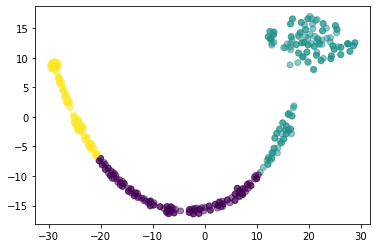

In [45]:
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=clustering.labels_, alpha=0.5)
plt.savefig("spectral_clustering_405.png")

In [46]:
# plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clustering.labels_, alpha=0.5)

In [47]:
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=2,eigen_solver='arpack',affinity="nearest_neighbors",
                                random_state=0).fit(X)
clustering.labels_

array([1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,

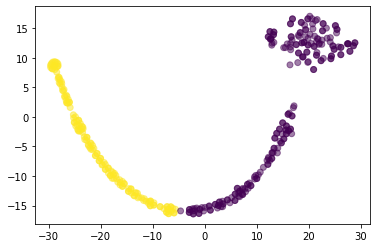

In [48]:
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=clustering.labels_, alpha=0.5)
plt.savefig("spectral_clustering_200.png")

## Normalized Input

In [49]:
from sklearn import preprocessing
scaler = preprocessing.MinMaxScaler().fit(X)
X_scaled = scaler.transform(X)

C:\Users\sguly\miniconda3\envs\hfpef\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]


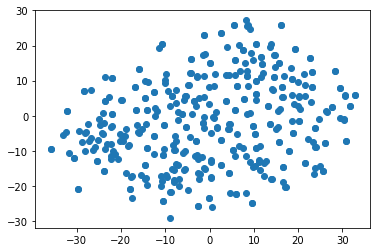

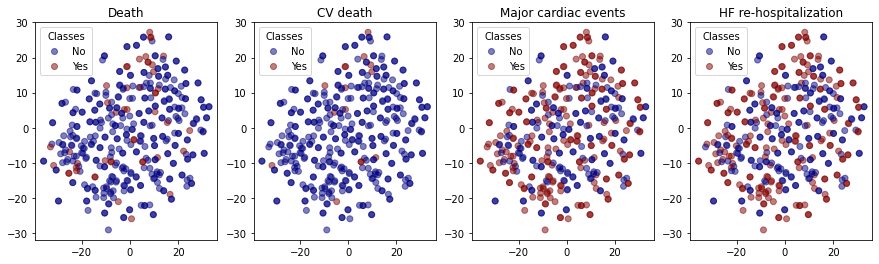

In [50]:
X_embedded = TSNE(n_components=2, init='random').fit_transform(X_scaled)
plot_tsne(X_embedded, y, lbl_colname)

[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]


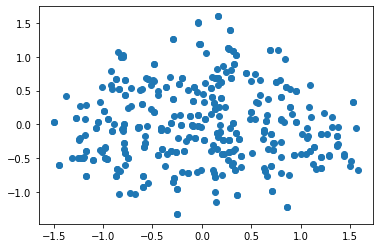

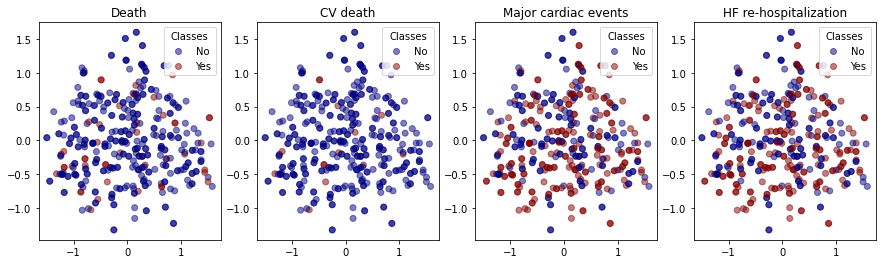

In [51]:
pca_model2 = PCA(n_components=.99)
X_pca = pca_model2.fit_transform(X_scaled)

# X_pca = PCA(n_components=2).fit_transform(X)
plot_tsne(X_pca, y, lbl_colname)

In [52]:
pca_model2.explained_variance_ratio_

array([0.1314838 , 0.08312712, 0.07990143, 0.071723  , 0.05826134,
       0.0536251 , 0.05155211, 0.04624339, 0.04403834, 0.03621419,
       0.03543276, 0.02879535, 0.02769002, 0.02518291, 0.02359072,
       0.01797726, 0.01760071, 0.01688441, 0.01593882, 0.01416291,
       0.01250243, 0.01165041, 0.01030952, 0.01007133, 0.00969239,
       0.00852686, 0.00841669, 0.0073188 , 0.00587479, 0.00499679,
       0.00450051, 0.00391677, 0.00357797, 0.00345055, 0.00307515,
       0.00283849])

In [53]:
sorted(zip(feature_list, pca_model2.components_[0].flatten()), key=lambda x: abs(x[1]), reverse=True)

[('Aspirin', 0.4821987361096385),
 ('AF', -0.43866286291359663),
 ('DM', 0.3470124919521647),
 ('MI', 0.33128903630761836),
 ('wide PP', 0.30211018604551826),
 ('Insulin', 0.23867479810755154),
 ("medial a'", 0.18825516391137606),
 ('CKD stage', 0.14254551267748522),
 ('GFR', -0.14240540269674914),
 ('TR Vmax', -0.13324840301001434),
 ('PP', 0.12148388634702295),
 ("average e/E'", 0.09099126039636463),
 ("lateral e/E'", 0.08892411472703197),
 ('MRA', -0.08673009431822956),
 ('1/2SBP', 0.08324932850026306),
 ('SBP', 0.08324932850026305),
 ('DBP', -0.07221820965423661),
 ("Mitral E/e'", 0.07100841412228621),
 ('Cr', 0.07041544705838416),
 ('LAVI', -0.06851717893397621),
 ("lateral E'", -0.06634178469744786),
 ('HT', 0.06500197600277587),
 ("medial E'", -0.06496308343186606),
 ('E/A', 0.05986567463477588),
 ('LA diameter', -0.05453093119643176),
 ('NTProBNP', 0.04301476464782425),
 ('LVH', 0.03723588919642423),
 ('Sex', -0.03656651252413713),
 ('LACI', 0.034587067358259296),
 ('ACE-i', -0

[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]


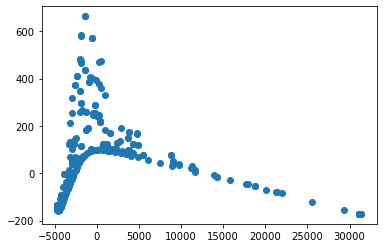

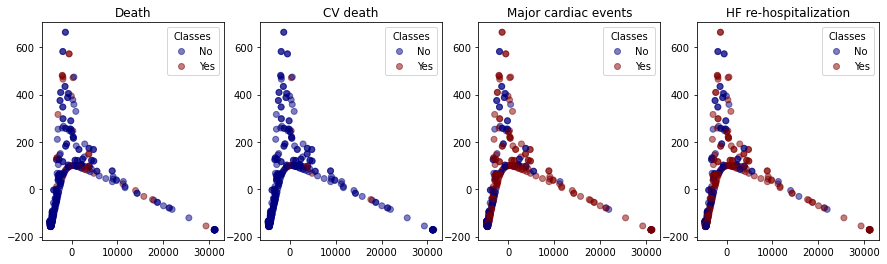

In [54]:
X_iso = Isomap(n_neighbors=10, n_components=2).fit_transform(X)
plot_tsne(X_iso, y, lbl_colname)